In [ ]:
%pip install torch torchvision matplotlib numpy wandb

Note: you may need to restart the kernel to use updated packages.


In [21]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import wandb

In [22]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [23]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # maps [0,1] -> [-1,1]
])

full_train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset_full = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

full_dataset = torch.utils.data.ConcatDataset([full_train_dataset, test_dataset_full])

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 56000
Val: 7000
Test: 7000


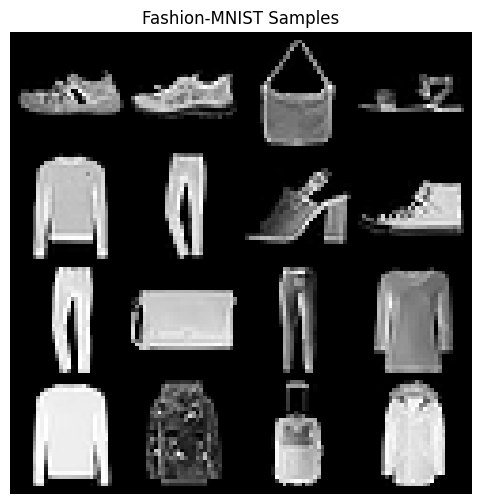

In [24]:
def denormalize(img):
    return img * 0.5 + 0.5

images, labels = next(iter(train_loader))
grid = make_grid(denormalize(images[:16]), nrow=4)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Fashion-MNIST Samples")
plt.show()

In [25]:
def get_noise(batch_size, latent_dim, device):
    return torch.randn(batch_size, latent_dim, device=device)

In [26]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(-1, 1, 28, 28)

In [27]:
class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)

In [28]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.ReLU(True)
        )
        
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 14 -> 28
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 7, 7)
        x = self.deconv(x)
        return x

In [29]:
class DCDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),   # 28 -> 14
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.model(x)

In [30]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 or classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [31]:
bce_loss = nn.BCEWithLogitsLoss()
mse_loss = nn.MSELoss()

def discriminator_bce_loss(real_logits, fake_logits):
    real_labels = torch.ones_like(real_logits)
    fake_labels = torch.zeros_like(fake_logits)
    
    real_loss = bce_loss(real_logits, real_labels)
    fake_loss = bce_loss(fake_logits, fake_labels)
    return real_loss + fake_loss

def generator_bce_loss(fake_logits):
    real_labels = torch.ones_like(fake_logits)
    return bce_loss(fake_logits, real_labels)

def discriminator_lsgan_loss(real_logits, fake_logits):
    real_labels = torch.ones_like(real_logits)
    fake_labels = torch.zeros_like(fake_logits)
    
    real_loss = mse_loss(real_logits, real_labels)
    fake_loss = mse_loss(fake_logits, fake_labels)
    return real_loss + fake_loss

def generator_lsgan_loss(fake_logits):
    real_labels = torch.ones_like(fake_logits)
    return mse_loss(fake_logits, real_labels)

def discriminator_wgan_loss(real_logits, fake_logits):
    return -(torch.mean(real_logits) - torch.mean(fake_logits))

def generator_wgan_loss(fake_logits):
    return -torch.mean(fake_logits)

In [32]:
def get_optimizer(params, optimizer_name="adam", lr=2e-4):
    optimizer_name = optimizer_name.lower()
    
    if optimizer_name == "sgd":
        return optim.SGD(params, lr=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        return optim.RMSprop(params, lr=lr)
    elif optimizer_name == "adam":
        return optim.Adam(params, lr=lr, betas=(0.5, 0.999))
    else:
        raise ValueError("optimizer_name must be 'sgd', 'rmsprop', or 'adam'")

In [33]:
def build_gan(model_type="vanilla", latent_dim=100):
    if model_type == "vanilla":
        G = VanillaGenerator(latent_dim=latent_dim).to(device)
        D = VanillaDiscriminator().to(device)
    elif model_type == "dcgan":
        G = DCGenerator(latent_dim=latent_dim).to(device)
        D = DCDiscriminator().to(device)
    else:
        raise ValueError("model_type must be 'vanilla' or 'dcgan'")
    
    G.apply(weights_init)
    D.apply(weights_init)
    
    return G, D

In [34]:
fixed_noise = get_noise(16, 100, device)

In [35]:
def train_gan(
    generator,
    discriminator,
    train_loader,
    g_optimizer,
    d_optimizer,
    latent_dim=100,
    epochs=10,
    loss_type="bce",
    model_type="vanilla",
    clip_value=0.01
):
    history = {
        "g_loss": [],
        "d_loss": []
    }
    
    fixed_noise = get_noise(16, latent_dim, device)
    generated_snapshots = []
    
    for epoch in range(epochs):
        generator.train()
        discriminator.train()
        
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        
        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            # -------------------------
            # Train Discriminator
            # -------------------------
            z = get_noise(batch_size, latent_dim, device)
            fake_images = generator(z).detach()
            
            d_optimizer.zero_grad()
            
            real_logits = discriminator(real_images)
            fake_logits = discriminator(fake_images)
            
            if loss_type == "bce":
                d_loss = discriminator_bce_loss(real_logits, fake_logits)
            elif loss_type == "lsgan":
                d_loss = discriminator_lsgan_loss(real_logits, fake_logits)
            elif loss_type == "wgan":
                d_loss = discriminator_wgan_loss(real_logits, fake_logits)
            else:
                raise ValueError("loss_type must be 'bce', 'lsgan', or 'wgan'")
            
            d_loss.backward()
            d_optimizer.step()
            
            if loss_type == "wgan":
                for p in discriminator.parameters():
                    p.data.clamp_(-clip_value, clip_value)
            
            # -------------------------
            # Train Generator
            # -------------------------
            z = get_noise(batch_size, latent_dim, device)
            g_optimizer.zero_grad()
            
            generated_images = generator(z)
            fake_logits = discriminator(generated_images)
            
            if loss_type == "bce":
                g_loss = generator_bce_loss(fake_logits)
            elif loss_type == "lsgan":
                g_loss = generator_lsgan_loss(fake_logits)
            elif loss_type == "wgan":
                g_loss = generator_wgan_loss(fake_logits)
            
            g_loss.backward()
            g_optimizer.step()
            
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
        
        avg_g_loss = epoch_g_loss / len(train_loader)
        avg_d_loss = epoch_d_loss / len(train_loader)
        
        history["g_loss"].append(avg_g_loss)
        history["d_loss"].append(avg_d_loss)
        
        # Save snapshot
        generator.eval()
        with torch.no_grad():
            fake_samples = generator(fixed_noise).cpu()
        generated_snapshots.append(fake_samples)
        
        print(f"Epoch [{epoch+1}/{epochs}] | G Loss: {avg_g_loss:.4f} | D Loss: {avg_d_loss:.4f}")
    
    return history, generated_snapshots

In [36]:
def plot_gan_history(history, title="GAN Training History"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["g_loss"], label="Generator Loss")
    plt.plot(history["d_loss"], label="Discriminator Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [37]:
def show_generated_images(images, title="Generated Images"):
    images = denormalize(images)
    grid = make_grid(images, nrow=4)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(title)
    plt.show()

Epoch [1/10] | G Loss: 1.3535 | D Loss: 1.0098
Epoch [2/10] | G Loss: 1.4164 | D Loss: 1.1312
Epoch [3/10] | G Loss: 1.1831 | D Loss: 1.2486
Epoch [4/10] | G Loss: 1.0815 | D Loss: 1.2540
Epoch [5/10] | G Loss: 1.0539 | D Loss: 1.2806
Epoch [6/10] | G Loss: 1.0931 | D Loss: 1.2757
Epoch [7/10] | G Loss: 1.0520 | D Loss: 1.2769
Epoch [8/10] | G Loss: 1.0650 | D Loss: 1.2816
Epoch [9/10] | G Loss: 1.0669 | D Loss: 1.2797
Epoch [10/10] | G Loss: 0.9925 | D Loss: 1.2992


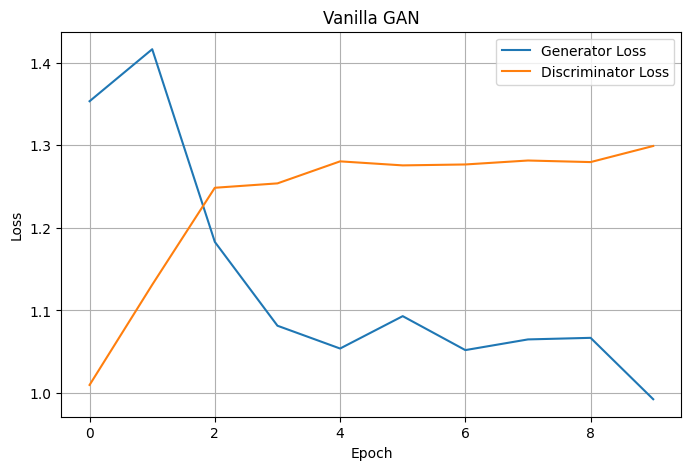

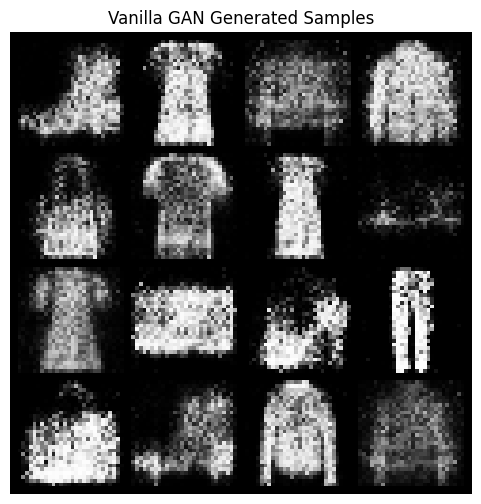

In [38]:
latent_dim = 100
model_type = "vanilla"
loss_type = "bce"
optimizer_name = "adam"
epochs = 10

G, D = build_gan(model_type=model_type, latent_dim=latent_dim)

g_optimizer = get_optimizer(G.parameters(), optimizer_name=optimizer_name, lr=2e-4)
d_optimizer = get_optimizer(D.parameters(), optimizer_name=optimizer_name, lr=2e-4)

history, snapshots = train_gan(
    generator=G,
    discriminator=D,
    train_loader=train_loader,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    latent_dim=latent_dim,
    epochs=epochs,
    loss_type=loss_type,
    model_type=model_type
)

plot_gan_history(history, title="Vanilla GAN")
show_generated_images(snapshots[-1], title="Vanilla GAN Generated Samples")

Epoch [1/10] | G Loss: 1.2366 | D Loss: 0.9640
Epoch [2/10] | G Loss: 1.2149 | D Loss: 0.9475
Epoch [3/10] | G Loss: 0.9559 | D Loss: 1.1901
Epoch [4/10] | G Loss: 0.9132 | D Loss: 1.2339
Epoch [5/10] | G Loss: 0.9012 | D Loss: 1.2433
Epoch [6/10] | G Loss: 0.8950 | D Loss: 1.2578
Epoch [7/10] | G Loss: 0.8768 | D Loss: 1.2753
Epoch [8/10] | G Loss: 0.8586 | D Loss: 1.2875
Epoch [9/10] | G Loss: 0.8488 | D Loss: 1.2944
Epoch [10/10] | G Loss: 0.8381 | D Loss: 1.3047


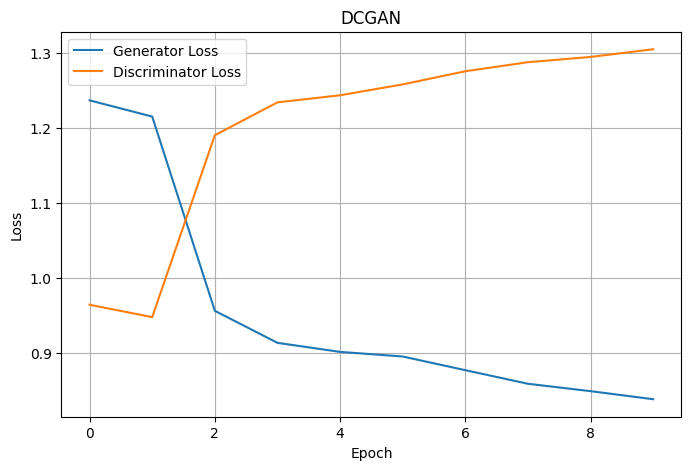

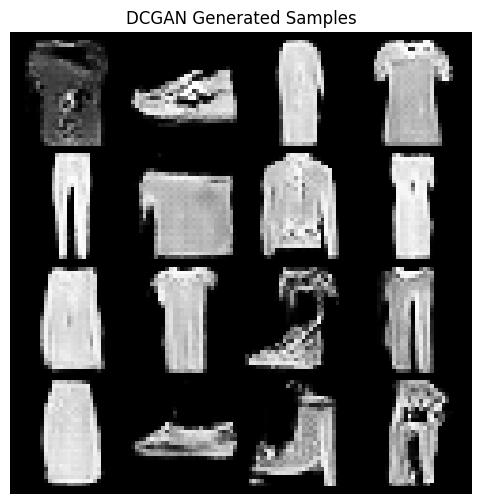

In [39]:
latent_dim = 100
model_type = "dcgan"
loss_type = "bce"
optimizer_name = "adam"
epochs = 10

G, D = build_gan(model_type=model_type, latent_dim=latent_dim)

g_optimizer = get_optimizer(G.parameters(), optimizer_name=optimizer_name, lr=2e-4)
d_optimizer = get_optimizer(D.parameters(), optimizer_name=optimizer_name, lr=2e-4)

history, snapshots = train_gan(
    generator=G,
    discriminator=D,
    train_loader=train_loader,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    latent_dim=latent_dim,
    epochs=epochs,
    loss_type=loss_type,
    model_type=model_type
)

plot_gan_history(history, title="DCGAN")
show_generated_images(snapshots[-1], title="DCGAN Generated Samples")

In [40]:
model_types = ["vanilla", "dcgan"]
loss_types = ["bce", "lsgan", "wgan"]
optimizer_names = ["sgd", "rmsprop", "adam"]

results = []

for model_type in model_types:
    for loss_type in loss_types:
        for optimizer_name in optimizer_names:
            print(f"\n=== {model_type.upper()} | {loss_type.upper()} | {optimizer_name.upper()} ===")
            
            G, D = build_gan(model_type=model_type, latent_dim=100)
            
            g_optimizer = get_optimizer(G.parameters(), optimizer_name=optimizer_name, lr=2e-4)
            d_optimizer = get_optimizer(D.parameters(), optimizer_name=optimizer_name, lr=2e-4)
            
            history, snapshots = train_gan(
                generator=G,
                discriminator=D,
                train_loader=train_loader,
                g_optimizer=g_optimizer,
                d_optimizer=d_optimizer,
                latent_dim=100,
                epochs=5,
                loss_type=loss_type,
                model_type=model_type
            )
            
            results.append({
                "model_type": model_type,
                "loss_type": loss_type,
                "optimizer": optimizer_name,
                "final_g_loss": history["g_loss"][-1],
                "final_d_loss": history["d_loss"][-1]
            })


=== VANILLA | BCE | SGD ===
Epoch [1/5] | G Loss: 0.6955 | D Loss: 0.9898
Epoch [2/5] | G Loss: 0.6790 | D Loss: 0.8572
Epoch [3/5] | G Loss: 0.6834 | D Loss: 1.0183
Epoch [4/5] | G Loss: 0.7680 | D Loss: 0.9822
Epoch [5/5] | G Loss: 1.0164 | D Loss: 0.7529

=== VANILLA | BCE | RMSPROP ===
Epoch [1/5] | G Loss: 0.7075 | D Loss: 1.3150
Epoch [2/5] | G Loss: 0.7715 | D Loss: 1.3270
Epoch [3/5] | G Loss: 0.7912 | D Loss: 1.3309
Epoch [4/5] | G Loss: 0.7886 | D Loss: 1.3384
Epoch [5/5] | G Loss: 0.7874 | D Loss: 1.3458

=== VANILLA | BCE | ADAM ===
Epoch [1/5] | G Loss: 1.2264 | D Loss: 1.0883
Epoch [2/5] | G Loss: 1.3585 | D Loss: 1.1516
Epoch [3/5] | G Loss: 1.1829 | D Loss: 1.2259
Epoch [4/5] | G Loss: 1.1572 | D Loss: 1.2418
Epoch [5/5] | G Loss: 1.0894 | D Loss: 1.2742

=== VANILLA | LSGAN | SGD ===
Epoch [1/5] | G Loss: 0.6440 | D Loss: 0.1169
Epoch [2/5] | G Loss: 0.5737 | D Loss: 0.1012
Epoch [3/5] | G Loss: 0.5542 | D Loss: 0.1280
Epoch [4/5] | G Loss: 0.5947 | D Loss: 0.1270
Epo

In [41]:
import pandas as pd

results_df = pd.DataFrame(results)
print(results_df)
results_df.to_csv("gan_experiment_results.csv", index=False)

   model_type loss_type optimizer  final_g_loss  final_d_loss
0     vanilla       bce       sgd      1.016406      0.752933
1     vanilla       bce   rmsprop      0.787374      1.345781
2     vanilla       bce      adam      1.089447      1.274186
3     vanilla     lsgan       sgd      0.721832      0.088706
4     vanilla     lsgan   rmsprop      0.324866      0.459209
5     vanilla     lsgan      adam      0.481334      0.408265
6     vanilla      wgan       sgd     -4.132769     -0.123617
7     vanilla      wgan   rmsprop     -0.278985     -0.033314
8     vanilla      wgan      adam     -0.054522     -0.044841
9       dcgan       bce       sgd      8.181354      0.013239
10      dcgan       bce   rmsprop      0.783384      1.343531
11      dcgan       bce      adam      0.929638      1.216287
12      dcgan     lsgan       sgd      0.949377      0.065890
13      dcgan     lsgan   rmsprop      0.295663      0.548795
14      dcgan     lsgan      adam      0.384952      0.434594
15      

In [42]:
torch.save(G.state_dict(), "generator_final.pth")
torch.save(D.state_dict(), "discriminator_final.pth")

In [43]:
def train_gan_wandb(generator, discriminator, train_loader, g_optimizer, d_optimizer, config):
    wandb.init(entity="anmolkumar_dtu", project="fashion-mnist-gan", config=config)
    
    latent_dim = config["latent_dim"]
    epochs = config["epochs"]
    loss_type = config["loss_type"]
    clip_value = config.get("clip_value", 0.01)

    fixed_noise = torch.randn(16, latent_dim, device=device)

    for epoch in range(epochs):
        generator.train()
        discriminator.train()

        g_epoch_loss = 0.0
        d_epoch_loss = 0.0

        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # -------------------------
            # Train Discriminator
            # -------------------------
            z = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(z).detach()

            d_optimizer.zero_grad()

            real_logits = discriminator(real_images)
            fake_logits = discriminator(fake_images)

            if loss_type == "bce":
                real_labels = torch.ones_like(real_logits)
                fake_labels = torch.zeros_like(fake_logits)

                d_real_loss = nn.BCEWithLogitsLoss()(real_logits, real_labels)
                d_fake_loss = nn.BCEWithLogitsLoss()(fake_logits, fake_labels)
                d_loss = d_real_loss + d_fake_loss

            elif loss_type == "lsgan":
                real_labels = torch.ones_like(real_logits)
                fake_labels = torch.zeros_like(fake_logits)

                d_real_loss = nn.MSELoss()(real_logits, real_labels)
                d_fake_loss = nn.MSELoss()(fake_logits, fake_labels)
                d_loss = d_real_loss + d_fake_loss

            elif loss_type == "wgan":
                d_loss = -(torch.mean(real_logits) - torch.mean(fake_logits))

            d_loss.backward()
            d_optimizer.step()

            if loss_type == "wgan":
                for p in discriminator.parameters():
                    p.data.clamp_(-clip_value, clip_value)

            # -------------------------
            # Train Generator
            # -------------------------
            z = torch.randn(batch_size, latent_dim, device=device)

            g_optimizer.zero_grad()
            generated_images = generator(z)
            fake_logits = discriminator(generated_images)

            if loss_type == "bce":
                real_labels = torch.ones_like(fake_logits)
                g_loss = nn.BCEWithLogitsLoss()(fake_logits, real_labels)

            elif loss_type == "lsgan":
                real_labels = torch.ones_like(fake_logits)
                g_loss = nn.MSELoss()(fake_logits, real_labels)

            elif loss_type == "wgan":
                g_loss = -torch.mean(fake_logits)

            g_loss.backward()
            g_optimizer.step()

            g_epoch_loss += g_loss.item()
            d_epoch_loss += d_loss.item()

        g_epoch_loss /= len(train_loader)
        d_epoch_loss /= len(train_loader)

        wandb.log({
            "epoch": epoch + 1,
            "generator_loss": g_epoch_loss,
            "discriminator_loss": d_epoch_loss,
            "g_lr": g_optimizer.param_groups[0]["lr"],
            "d_lr": d_optimizer.param_groups[0]["lr"]
        })

        if epoch % 2 == 0:
            generator.eval()
            with torch.no_grad():
                sample_images = generator(fixed_noise).cpu()

            # convert from [-1,1] to [0,1]
            sample_images = (sample_images + 1) / 2.0

            wandb.log({
                "generated_samples": [
                    wandb.Image(sample_images[i].squeeze().numpy())
                    for i in range(min(4, sample_images.size(0)))
                ]
            })

        print(f"Epoch {epoch+1}: G_loss={g_epoch_loss:.4f}, D_loss={d_epoch_loss:.4f}")

    wandb.finish()

In [44]:
def build_gan_models(model_type="vanilla", latent_dim=100):
    if model_type == "vanilla":
        generator = VanillaGenerator(latent_dim=latent_dim).to(device)
        discriminator = VanillaDiscriminator().to(device)
    elif model_type == "dcgan":
        generator = DCGenerator(latent_dim=latent_dim).to(device)
        discriminator = DCDiscriminator().to(device)
    else:
        raise ValueError("model_type must be 'vanilla' or 'dcgan'")
    
    return generator, discriminator

def get_gan_optimizer(model, optimizer_name="adam", lr=2e-4):
    if optimizer_name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr)
    elif optimizer_name == "adam":
        return optim.Adam(model.parameters(), lr=lr, betas=(0.5, 0.999))
    else:
        raise ValueError("optimizer_name must be 'sgd', 'rmsprop', or 'adam'")
    
model_types = ["vanilla", "dcgan"]
loss_types = ["bce", "lsgan", "wgan"]
optimizers_list = ["sgd", "rmsprop", "adam"]

for model_type in model_types:
    for loss_type in loss_types:
        for opt_name in optimizers_list:
            generator, discriminator = build_gan_models(
                model_type=model_type,
                latent_dim=100
            )

            g_optimizer = get_gan_optimizer(generator, optimizer_name=opt_name, lr=2e-4)
            d_optimizer = get_gan_optimizer(discriminator, optimizer_name=opt_name, lr=2e-4)

            config = {
                "model": model_type.upper(),
                "latent_dim": 100,
                "loss_type": loss_type,
                "optimizer": opt_name,
                "epochs": 5,
                "lr": 2e-4,
                "clip_value": 0.01
            }

            train_gan_wandb(
                generator=generator,
                discriminator=discriminator,
                train_loader=train_loader,
                g_optimizer=g_optimizer,
                d_optimizer=d_optimizer,
                config=config
            )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/mckyzcky/.netrc.
wandb: Currently logged in as: anmolkumar_25afi01 (anmolkumar_dtu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1: G_loss=0.7912, D_loss=0.8039
Epoch 2: G_loss=0.7439, D_loss=0.8508
Epoch 3: G_loss=0.7860, D_loss=0.9451
Epoch 4: G_loss=0.9766, D_loss=0.8297
Epoch 5: G_loss=1.4743, D_loss=0.5065


d_lr,▁▁▁▁▁
discriminator_loss,▆▆█▆▁
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,▁▁▁▃█
d_lr,0.0002
discriminator_loss,0.50649
epoch,5
g_lr,0.0002
generator_loss,1.47431


Epoch 1: G_loss=0.7681, D_loss=1.2566
Epoch 2: G_loss=0.8371, D_loss=1.2757
Epoch 3: G_loss=0.8561, D_loss=1.2793
Epoch 4: G_loss=0.8627, D_loss=1.2787
Epoch 5: G_loss=0.8573, D_loss=1.2868


d_lr,▁▁▁▁▁
discriminator_loss,▁▅▆▆█
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,▁▆███
d_lr,0.0002
discriminator_loss,1.28676
epoch,5
g_lr,0.0002
generator_loss,0.85728


...

d_lr,▁▁▁▁▁
discriminator_loss,█▄▃▃▁
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,█▆▁▃█
d_lr,0.0002
discriminator_loss,-0.07649
epoch,5
g_lr,0.0002
generator_loss,-0.00966


Epoch 1: G_loss=-0.0101, D_loss=-0.0002
Epoch 2: G_loss=-0.0083, D_loss=-0.0051
Epoch 3: G_loss=-0.0038, D_loss=-0.0036
Epoch 4: G_loss=-0.0042, D_loss=-0.0025
Epoch 5: G_loss=-0.0056, D_loss=-0.0019


d_lr,▁▁▁▁▁
discriminator_loss,█▁▃▅▆
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,▁▃██▆
d_lr,0.0002
discriminator_loss,-0.00188
epoch,5
g_lr,0.0002
generator_loss,-0.0056


Epoch 1: G_loss=-0.0074, D_loss=-0.0001
Epoch 2: G_loss=-0.0086, D_loss=-0.0019
Epoch 3: G_loss=-0.0090, D_loss=-0.0030
Epoch 4: G_loss=-0.0075, D_loss=-0.0018
Epoch 5: G_loss=-0.0059, D_loss=-0.0017


d_lr,▁▁▁▁▁
discriminator_loss,█▄▁▄▄
epoch,▁▃▅▆█
g_lr,▁▁▁▁▁
generator_loss,▅▂▁▄█
d_lr,0.0002
discriminator_loss,-0.00173
epoch,5
g_lr,0.0002
generator_loss,-0.00585
